## Car Fuel Efficiency Project

For this project I would use the CRISP-DM medothology explained previously.

## 1. Business Understanding

A car's fuel efficiency can be crucial when when deciding which car to buy. This infomation can be obtain directly from the manufacturer's website, but when it is not available, a more detailed analysis is needed to estimate a car's actual fuel efficency. 

That's why it's necessary to build a model capable of peforming this calculation based on real data from other cars and models similar to the one for which we want to estimate the fuel efficiency.

We are going to use the provided dataset for this project, it's available on:

- wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

## 2. Data Understanding

> Here we are going to start importing the libraries needed, read the data and look for any missing or interesting values.

In [111]:
import pandas as pd
import numpy as np
import seaborn as sb
from matplotlib import pyplot as plt
%matplotlib inline

In [112]:
org_df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')
len(org_df)

10000

In [113]:
org_df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [7]:
org_df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [9]:
org_df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [51]:
org_df.horsepower.median()

np.float64(254.0)

In [64]:
org_df.model_year.max()

np.int64(2024)

> We can see there's a good amount of data, the columns are already normalized, and there are some null values that we may need to handle later. <br>
> Based on the available data and our objective of predicting a car's fuel efficiency, for this first iteration, we are going to use the following data
> - engine_displacement
> - horse power
> - vehicle_weight
> - model_year
> <br> Our ***y*** reference for training this model is going to be:
> - fuel_efficiency_mpg
>  <br> Now we are going to look at how our target variable is distributed, and whether we need to make some adjustments to achieve a nomal distribution.

Text(0.5, 1.0, 'Distribution of fuel efficiency')

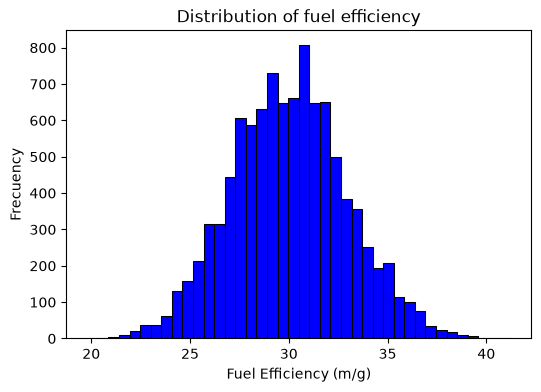

In [17]:
plt.figure(figsize=(6,4))
sb.histplot(org_df.fuel_efficiency_mpg, bins=40, color='blue', alpha=1)
plt.ylabel('Frecuency')
plt.xlabel('Fuel Efficiency (m/g)')
plt.title('Distribution of fuel efficiency')

Text(0.5, 1.0, 'Distribution of fuel efficiency')

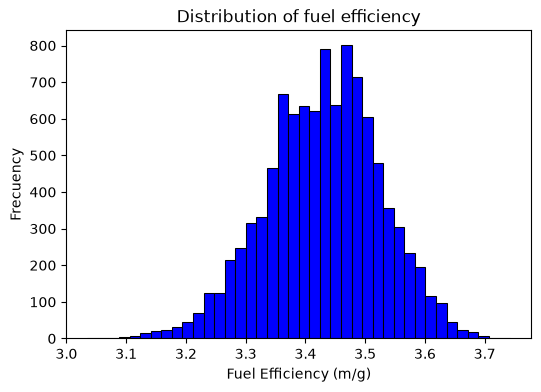

In [78]:
log_fuel_efficiency_mpg = np.log1p(org_df.fuel_efficiency_mpg)

plt.figure(figsize=(6,4))
sb.histplot(log_fuel_efficiency_mpg, bins=40, color='blue', alpha=1)
plt.ylabel('Frecuency')
plt.xlabel('Fuel Efficiency (m/g)')
plt.title('Distribution of fuel efficiency')

>As seen in the graph, our target variable has an approximately normal distribution, so there's no need to apply a logarithmic transformatio

## 3. Data Preparation

> Here, we are going to split the data so that we end up with a training, validation, and test datasets.

In [98]:
np.random.seed(42)
n = len(org_df)

val_long = int(0.2 * n)
test_long = int(0.2 * n)
training_long = n - (val_long + test_long)

> Now, by randomizing the values from the original dataset, we distribute them into the three datasets.

In [99]:
idx = np.arange(n)
np.random.shuffle(idx)

shuffled_df = org_df.iloc[idx]

training_df = shuffled_df.iloc[:training_long].copy()
validation_df = shuffled_df.iloc[training_long:training_long+val_long].copy()
test_df = shuffled_df.iloc[training_long+val_long:].copy()

> We need to separe the target variable from the three datasets

In [100]:
y_training = training_df.fuel_efficiency_mpg
y_validation = validation_df.fuel_efficiency_mpg
y_test = test_df.fuel_efficiency_mpg

del training_df['fuel_efficiency_mpg']
del validation_df['fuel_efficiency_mpg']
del test_df['fuel_efficiency_mpg']

## 4. Modeling

> As we are implenting linear regression we can use the same formulas for the regression method and rmse than in the last exercise.

In [101]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [102]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [103]:
def rmse(y, y_pred, n_round):
    error = y_pred - y
    mse = (error ** 2).mean()
    return round(np.sqrt(mse), n_round)

> For the missing data, we need to test two scenarios, one filling the information with zeros and other filling thhem with the mean value for the variable.

In [104]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight']

In [105]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2024 - df.model_year
    features.append('age')
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [106]:
def prepare_X_mean(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2024 - df.model_year
    features.append('age')
    
    df_num = df[features]
    df_num = df_num.fillna(df_num.mean())
    X = df_num.values
    return X 

> Now, we need to compare which method for the X preparation is better. We are going to use the linear regression method without regularization

In [107]:
x_zeros = prepare_X(training_df)
w_0_zeros, w_zeros = train_linear_regression(x_zeros, y_training)

x_val_zeros  = prepare_X(validation_df)
y_zeros_predict = w_0_zeros + x_val_zeros.dot(w_zeros)

rmse(y_validation, y_zeros_predict, 3)

np.float64(2.205)

In [108]:
x_mean = prepare_X_mean(training_df)
w_0_mean, w_mean = train_linear_regression(x_mean, y_training)

x_val_mean = prepare_X_mean(validation_df)
y_mean_predict = w_0_mean + x_val_mean.dot(w_mean)

rmse(y_validation, y_mean_predict, 3)

np.float64(2.202)

> Applying regularized regression method for differnt r values

In [110]:
x_train = prepare_X(training_df)
x_validation = prepare_X(validation_df)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(x_train, y_training, r=r)
    y_prediction = w_0 + x_validation.dot(w)
    
    print(f"w0 = {w_0}, w = {w}, r = {r}, rmse = {rmse(y_validation, y_prediction, 4)}")

w0 = 52.86013086866814, w = [-1.51505520e-03 -4.74024796e-06 -3.95418397e-03 -1.02146785e-01], r = 0, rmse = 2.2053
w0 = 52.83663212092368, w = [-1.51381969e-03 -4.09629096e-06 -3.94946448e-03 -1.02136858e-01], r = 0.01, rmse = 2.2053
w0 = 52.626079808247994, w = [-1.50274938e-03  1.67366240e-06 -3.90717713e-03 -1.02047906e-01], r = 0.1, rmse = 2.205
w0 = 50.609314530890586, w = [-1.39671295e-03  5.69410632e-05 -3.50212984e-03 -1.01195888e-01], r = 1, rmse = 2.2064
w0 = 43.24390673468037, w = [-0.00100946  0.00025879 -0.00202286 -0.09808419], r = 5, rmse = 2.2704
w0 = 36.587897511627986, w = [-0.0006595   0.0004412  -0.00068607 -0.09527209], r = 10, rmse = 2.4023
w0 = 9.70365235119558, w = [ 0.00075395  0.0011783   0.00471334 -0.08390865], r = 100, rmse = 3.4217


> Trying with different seed to randomize

In [119]:
scores = []

for seedn in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(seedn)
    n = len(org_df)

    val_long = int(0.2 * n)
    test_long = int(0.2 * n)
    training_long = n - (val_long + test_long)

    idx = np.arange(n)
    np.random.shuffle(idx)
    
    shuffled_df = org_df.iloc[idx]
    
    training_df = shuffled_df.iloc[:training_long].copy()
    validation_df = shuffled_df.iloc[training_long:training_long+val_long].copy()
    test_df = shuffled_df.iloc[training_long+val_long:].copy()

    y_training = training_df.fuel_efficiency_mpg
    y_validation = validation_df.fuel_efficiency_mpg
    y_test = test_df.fuel_efficiency_mpg

    del training_df['fuel_efficiency_mpg']
    del validation_df['fuel_efficiency_mpg']
    del test_df['fuel_efficiency_mpg']

    x_train = prepare_X(training_df)
    x_validation = prepare_X(validation_df)
    w_0, w = train_linear_regression(x_train, y_training)
    y_prediction = w_0 + x_validation.dot(w)

    score = rmse(y_validation, y_prediction, 4)
    scores.append(score)
    print(f"w0 = {w_0}, w = {w}, r = {r}, rmse = {score}")

w0 = 52.99055429996036, w = [-0.00130691 -0.00017882 -0.00409437 -0.10050366], r = 100, rmse = 2.2392
w0 = 53.02088065399218, w = [-1.44861835e-03 -2.78044732e-05 -4.01829035e-03 -1.01103358e-01], r = 100, rmse = 2.2021
w0 = 52.913192891852674, w = [-0.00134353 -0.00025474 -0.00404    -0.10165705], r = 100, rmse = 2.1634
w0 = 52.16187373008488, w = [-0.00144805  0.00017049 -0.00383872 -0.10103501], r = 100, rmse = 2.2044
w0 = 52.371690062068964, w = [-0.00134773 -0.0004606  -0.00388073 -0.1043776 ], r = 100, rmse = 2.2019
w0 = 52.22850256006277, w = [-0.00142536  0.00039283 -0.0038777  -0.10083293], r = 100, rmse = 2.2458
w0 = 52.29628082414115, w = [-0.00127187  0.00024781 -0.00395862 -0.10210873], r = 100, rmse = 2.2697
w0 = 52.96498586065679, w = [-0.0012403  -0.00040721 -0.00408596 -0.10275857], r = 100, rmse = 2.1908
w0 = 52.38104204530408, w = [-0.00138219 -0.00025767 -0.00389941 -0.10020712], r = 100, rmse = 2.2166
w0 = 53.078087219348504, w = [-0.00130127 -0.00047211 -0.0040918

In [120]:
deviation = round(np.std(scores),3)
deviation

np.float64(0.029)

> Combining datasets for seed 9

In [123]:
np.random.seed(9)
n = len(org_df)

val_long = int(0.2 * n)
test_long = int(0.2 * n)
training_long = n - (val_long + test_long)

idx = np.arange(n)
np.random.shuffle(idx)

shuffled_df = org_df.iloc[idx]
    
training_df = shuffled_df.iloc[:training_long].copy()
validation_df = shuffled_df.iloc[training_long:training_long+val_long].copy()
test_df = shuffled_df.iloc[training_long+val_long:].copy()

y_training = training_df.fuel_efficiency_mpg
y_validation = validation_df.fuel_efficiency_mpg
y_test = test_df.fuel_efficiency_mpg

del training_df['fuel_efficiency_mpg']
del validation_df['fuel_efficiency_mpg']
del test_df['fuel_efficiency_mpg']

full_training_df = pd.concat([training_df, validation_df])
full_training_df = full_training_df.reset_index(drop=True)

y_full_training = np.concatenate([y_training, y_validation])

x_full_training = prepare_X(full_training_df) 
x_test = prepare_X(test_df)

w_0, w = train_linear_regression_reg(x_full_training, y_full_training, r=0.001)

y_prediction = w_0 + x_test.dot(w)

score = rmse(y_test, y_prediction, 3)
print(f"w0 = {w_0}, w = {w}, r = {r}, rmse = {score}")

w0 = 52.86415996469959, w = [-0.00135365 -0.00044004 -0.00401609 -0.10161566], r = 100, rmse = 2.236
